# Importing Classes

You can import classes from the `frank2d` package for either CPU or GPU execution.

#### **1.CPU (Default)**

By default, all classes are executed on the CPU. You can import them directly from the main package:

```python
from frank2d import Frank2D, Gridding, AnotherClassName
```

#### **2.GPU**

There are two equivalent ways to use the GPU-accelerated classes:

**1. Importing from the GPU submodule**.
You can directly import from the `frank2d.gpu` directory. The class names here are identical to their CPU counterparts.

```python
from frank2d.gpu import Frank2D, Gridding, AnotherClassName
```

**2. Using the `use_gpu` parameter**.
Alternatively, you can import the classes from the main package (just like the CPU version) and pass the `use_gpu=True` parameter when instantiating the class.

```python
from frank2d import Frank2D, Gridding, AnotherClassName

model = Frank2D(Rmax, N, use_gpu=True)
```

#### **Notes**
> **Note 1.** You can choose whichever method works best for you. Just remember to be consistent, this is, if you opt for the second method, make sure to apply the same `use_gpu=True` parameter across all classes within the same pipeline (or connected to the same `Frank2D` instance).

> **Note 2.** To visualize the specific helper of each class or method in CPU or GPU, the correct way of doing it is using the 2.1 way of importing.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from frank2d import *

# Loading Data

You can load data from various file formats (using `.npz` is highly recommended to save memory). The key requirement is that the data must be parsed into a Python dictionary containing the following keys and specific units:

* `u`: u-coordinates (in wavelengths, λ)
* `v`: v-coordinates (in wavelengths, λ)
* `vis`: Complex visibilities (in Janskys, Jy)
* `weights`: Statistical weights (typically in 1/Jy²)

For this example, we use mock data representing a disk that features a blob on the left side, located on its first inner ring.

In [2]:
# Directory of data
dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }


# What values of $R_{max}$ and $N$ should I use?

The important parameters for frank2d are:

* $R_{max}$ represents the maximum radial extent of your grid in arcseconds. To provide a safe padding margin, we recommend setting this to about three times the physical outer radius of your source ($R_{out}$): $R_{max} \approx 3 R_{out}$.
* $N$ represents the number of collocation points used to sample the model.

Following the Nyquist-Shannon sampling theorem, a continuous signal can be perfectly reconstructed if it is sampled at a rate at least twice its highest frequency. In the context of the *uv*-plane, this translates to $u_{max} \approx \frac{N_u}{2} \Delta u$ (with the same logic applying to $v_{max}$). 

If we assume a symmetric grid where $N_u = N_v = N$, and we define $Q_{max} = \sqrt{u_{max}^2 + v_{max}^2}$ as the maximum baseline distance, the theorem indicates that $N$ should be at least $4 Q_{max} R_{max}$ (assuming $R_{max}$ is in radians). 

To ensure a safe margin and optimal sampling, we recommend using a top boundary factor of 5 instead of 4. Furthermore, because of how discrete spatial grids are constructed, **$N$ must be an even number**. This ensures the phase center $(0,0)$ is explicitly evaluated in the grid. Using an odd $N$ will shift the origin by a fraction of a pixel, introducing artificial phase gradients that manifest as diagonal aliasing stripes in the image plane.

Taking the unit conversion into account, the robust formula to calculate $N$ is:

$$N = \text{Nearest even integer} \ge \left( 5 \, Q_{max} \frac{R_{max}}{\text{rad\_to\_arcsec}} \right)$$

This is a strong recommendation for robust sampling, but you are free to experiment with different values as long as you keep the Nyquist limit and the even-number parity in mind.

In helpers.py there is a function that allows us to get the optimal N for given $R_{max}$.

In [3]:
q = np.hypot(uvtable['u'], uvtable['v'])
Qmin = np.min(q)
Qmax = np.max(q)

Rmax = 3*rout
N = get_optimal_N(Rmax, Qmax)


print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


# Power Spectrum

The 1D power spectrum of the visibilities is crucial data to keep in mind for the subsequent optimization step. According to Jennings et al. (2020), the amplitude values along the diagonal of the Gaussian Process covariance matrix in Frankenstein follow the primary slope of this data.

**Why is this important?**
By analyzing the power spectrum, you can establish an empirical baseline for your GP hyperparameter priors. 

**Practical Tip:** Before proceeding to the optimization phase, it is highly recommended to plot the binned 1D visibilities (amplitude vs. baseline distance, denoted as $q$). This visual inspection allows you to verify the expected power-law decay of the visibilities.

/tmp/ipykernel_1469016/4254771734.py:11: RuntimeWarning: divide by zero encountered in log10
  logx = np.log10(binned_vis.uv)
/tmp/ipykernel_1469016/4254771734.py:12: RuntimeWarning: divide by zero encountered in log10
  logy = np.log10(np.abs(binned_vis.V))


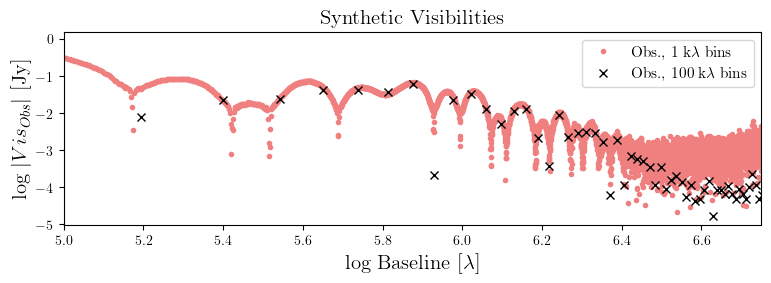

In [7]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 2.5))
plt.plot(logx, logy, marker=ms[0], ls='None', c ='lightcoral', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size=15)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size=15)
plt.legend(loc = 'best', fontsize=11)
plt.title("Synthetic Visibilities", size=15)
plt.xlim(5, 6.75)
plt.show()

# Frankenstein2D: Gridding

In `frank2d`, before proceeding to the fitting stage, the continuous visibility data must be gridded to enable the use of the Fast Fourier Transform (FFT). 

This step is handled by the `Gridding` class, which computes a weighted average of the visibilities within each grid cell. This procedure effectively applies **natural weighting** to the data. By weighting the visibilities according to the natural density of the sampled *uv* points, this approach maximizes the overall sensitivity (signal-to-noise ratio) of the dataset.

Instead of manually initializing the `Gridding` class and calling its `run` method, you can perform this operation directly using the `process_vis` method from the `Frank2D` class. This provides a straightforward way to process and inspect your gridded input data before initializing the fit.

In [8]:
frank2d0 = Frank2D(N, Rmax, verbose=True, use_gpu=True)

In [9]:
help(frank2d0)

Help on Frank2D in module frank2d.gpu.frank2d_gpu object:

class Frank2D(builtins.object)
 |  Frank2D(N, Rmax, verbose=False)
 |
 |  Methods defined here:
 |
 |  __init__(self, N, Rmax, verbose=False)
 |      Initialize the Frank2D class.
 |      Parameters:
 |      -----------
 |      N : int
 |          Number of collocation points in each dimension (image will be NxN).
 |      Rmax : float
 |          Radius of the image in arcseconds.
 |      verbose : bool
 |          Whether to print verbose messages during the fitting process.
 |
 |  build_full_model(self)
 |      Build the full visibility model from the weighted and non-weighted solution.
 |      Return
 |      -------
 |      V_full : 2D array, unit: Jy
 |          Full visibility model on a Nx x Ny grid.
 |
 |  check_bounds(self, u, v)
 |      Function to check if the frequencies are within the bounds of the
 |      grid (the uv domain is properly covered).
 |      Parameters
 |      ----------
 |      u : 1D array, unit = la

In [10]:
frank2d0.dx # pixel resolution in arcsec.

0.009316770186335404

In [11]:
frank2d0.process_vis(uvtable)

===>  Setting gridded data...


In [12]:
# The get method is only necessary for CuPy arrays, it returns the data to the CPU as a numpy array.
u, v = frank2d0.gridded_data['u'].get(), frank2d0.gridded_data['v'].get()
vis = frank2d0.gridded_data['vis'].get()
weights = frank2d0.gridded_data['weights']

/tmp/ipykernel_1469016/1402667743.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(vis.reshape(N,N))),


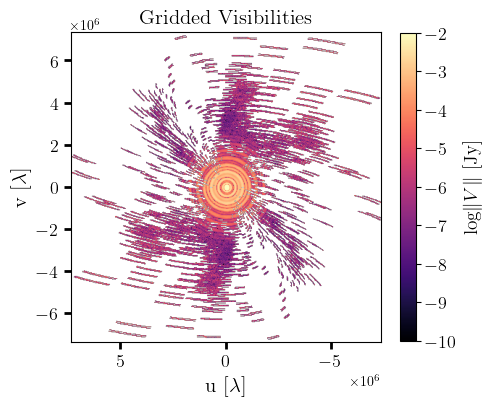

In [13]:
zoom_factor = 1.5

plt.figure(figsize=(5,5))
plt.imshow(np.log(np.abs(vis.reshape(N,N))), 
            extent = [u.max(), u.min(), v.min(), v.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)
plt.title('Gridded Visibilities', size=15)
plt.ylim(v.min()/zoom_factor, v.max()/zoom_factor)
plt.xlim(u.max()/zoom_factor, u.min()/zoom_factor)
plt.xlabel(r'u [$\lambda$]', size=15, weight='extra bold')
plt.ylabel(r'v [$\lambda$]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'log$\| V \|$ [Jy]', size=14)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)
plt.show()

### Or using directly the Gridding class

In [16]:
# We can use directly the Gridding class instead of calling the 
# method that do the job fron the main class Frank2D.

import cupy as cp
grid = Gridding(frank2d0._Rmax, frank2d0._FT, use_gpu = True)

In [17]:
help(grid)

Help on Gridding in module frank2d.gpu.process_vis_gpu object:

class Gridding(builtins.object)
 |  Gridding(Rmax, FT, verbose=False)
 |
 |  Methods defined here:
 |
 |  __init__(self, Rmax, FT, verbose=False)
 |      Class to grid visibilities in a regular grid (CuPy backend).
 |      Parameters
 |      ----------
 |      N : int
 |          Number of pixels in one side of the image.
 |      Rmax : float
 |          Maximum radius of the image in radians.
 |      FT : FourierTransform object
 |          Object that contains the Fourier Transform parameters.
 |
 |  edges_centers(self, bin_centers)
 |      Function to calculate the edges of the bins for gridding
 |      with the uv-plane shifted.
 |      Parameters
 |      ----------
 |      bin_centers : 1D array, unit = lambda
 |          Frequencies where the bins are centered.
 |      Returns
 |      -------
 |      bin_edges : 1D array, unit = lambda
 |          Edges of the bins.
 |
 |  enforce_hermitian_symmetry(self, vis, wts)
 

In [ ]:
u_, v_, vis_, weights_ = uvtable['u'], uvtable['v'], uvtable['vis'], uvtable['weights']
u_, v_, vis_, weights_ = cp.asarray(u_), cp.asarray(v_), cp.asarray(vis_), cp.asarray(weights_)
u, v, vis, weights = grid.run(u_, v_, vis_, weights_, hermitian = True)

> **Note:** This code is made for you as well to play indepently with the classes that allow the pipeline runs.  As you noticed, you can use directly the preprocess_vis method to grid the visibilities, or you can play directly with the class Gridding. More freedom comes with more responsability, so if you are using the version in GPU, remember to use cp.array instead of np.array types.

# Dirty Image

We can inspect the dirty image by directly calculating the Fast Fourier Transform (FFT) of the gridded visibilities. 

Because the *uv*-plane is intrinsically sparsely sampled, this direct transform yields an image that is convolved with the interferometric point spread function (PSF), commonly referred to as the "dirty beam." Since we applied **natural weighting** during the gridding step, this dirty image will feature optimal point-source sensitivity, albeit at the cost of a slightly broader beam and more pronounced sidelobes.

Inspecting the dirty image is a highly recommended sanity check. For instance, if you are using our mock dataset, this is the stage where you should visually confirm the overall disk structure and spot the blob on the first outer ring before proceeding to the formal modeling process.

In [10]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

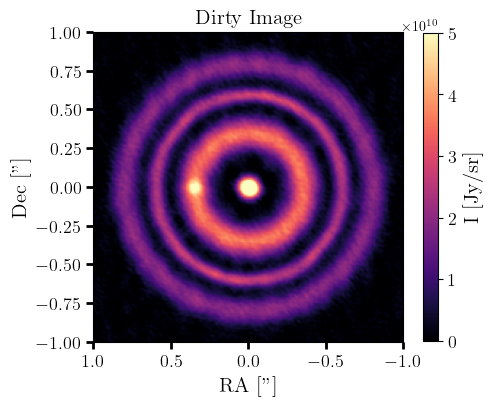

In [11]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmax=5e10, vmin = 0)
plt.figure(figsize=(5,5))
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma',
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
plt.title('Dirty Image', size=15)
plt.xlabel('RA ["]', size=15, weight='extra bold')
plt.ylabel('Dec ["]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)